<a href="https://colab.research.google.com/github/Atharvu2/intro-to-ml-Atharvu2/blob/main/iai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===========================
# INSTALL DEPENDENCIES
# ===========================
# pip install yfinance pandas numpy matplotlib scikit-learn statsmodels torch ta
!pip install ta --quiet
import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
import ta

# ===========================
# 1. LOAD DATA
# ===========================
def load_data(ticker="AAPL"):
    df = yf.download(ticker, period="5y", auto_adjust=True)

    df = df[['Open','High','Low','Close','Volume']]
    df.columns = ['Open','High','Low','Close','Volume']
    df = df.squeeze()  # removes extra dimension if present

    df.dropna(inplace=True)
    return df

# ===========================
# 2. FEATURE ENGINEERING
# ===========================
def add_features(df):
    df['SMA7'] = df['Close'].rolling(7).mean()
    df['SMA21'] = df['Close'].rolling(21).mean()

    df['EMA12'] = df['Close'].ewm(span=12).mean()
    df['EMA26'] = df['Close'].ewm(span=26).mean()

    df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()
    df['ATR'] = ta.volatility.AverageTrueRange(
        df['High'], df['Low'], df['Close']).average_true_range()

    df['Returns'] = df['Close'].pct_change()
    df['Volatility'] = df['Returns'].rolling(10).std()

    df.dropna(inplace=True)
    return df

# ===========================
# 3. ARIMA MODEL (Residuals)
# ===========================
def fit_arima(series):
    model = ARIMA(series, order=(5,1,0))
    model_fit = model.fit()
    return model_fit

def get_residuals(model, series):
    preds = model.predict(start=1, end=len(series)-1)
    residuals = series[1:] - preds
    return residuals

# ===========================
# 4. DATA PREPARATION
# ===========================
def create_sequences(data, target, seq_len=60):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

# ===========================
# 5. LSTM WITH ATTENTION + MC DROPOUT
# ===========================
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, 128, batch_first=True)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.attn = Attention(64)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x,_ = self.lstm1(x)
        x,_ = self.lstm2(x)
        x = self.attn(x)
        x = self.dropout(x)
        return self.fc(x)

# ===========================
# 6. TRAIN MODEL
# ===========================
def train_model(model, X, y):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).view(-1,1)

    for epoch in range(20):
        model.train()
        optimizer.zero_grad()
        output = model(X_t)
        loss = loss_fn(output, y_t)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

# ===========================
# 7. MC DROPOUT PREDICTION
# ===========================
def mc_predict(model, X, n_samples=100):
    model.train()  # keep dropout ON

    preds = []
    X_t = torch.tensor(X, dtype=torch.float32)

    for _ in range(n_samples):
        preds.append(model(X_t).detach().numpy())

    preds = np.array(preds)

    mean = preds.mean(axis=0)
    std = preds.std(axis=0)

    return mean, std

# ===========================
# 8. REGIME DETECTION
# ===========================
def detect_regime(volatility):
    if volatility > np.percentile(volatility, 90):
        return "Volatile"
    elif volatility.mean() > 0:
        return "Trending"
    else:
        return "Mean-Reverting"

# ===========================
# MAIN PIPELINE
# ===========================
df = load_data()
df = add_features(df)

# ARIMA
arima_model = fit_arima(df['Close'])
residuals = get_residuals(arima_model, df['Close'])

# Align data
df = df.iloc[1:]
df['Residual'] = residuals

# Scaling
scaler = MinMaxScaler()
features = df.drop(columns=['Residual'])
features_scaled = scaler.fit_transform(features)

# Sequences
X, y = create_sequences(features_scaled, df['Residual'].values)

# Train/Test split
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Model
model = LSTMModel(input_dim=X.shape[2])
model = train_model(model, X_train, y_train)

# Predictions with uncertainty
mean, std = mc_predict(model, X_test)

# Final prediction
arima_preds = arima_model.predict(start=split+60, end=len(df)-1)

final_pred = arima_preds.values.reshape(-1,1) + mean

lower = final_pred - 1.96 * std
upper = final_pred + 1.96 * std

print("Final Prediction Sample:", final_pred[:5])
print("Confidence Interval Sample:", lower[:5], upper[:5])

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Epoch 0, Loss: 7.7620
Epoch 1, Loss: 7.7497
Epoch 2, Loss: 7.7501
Epoch 3, Loss: 7.7496
Epoch 4, Loss: 7.7497
Epoch 5, Loss: 7.7475
Epoch 6, Loss: 7.7460
Epoch 7, Loss: 7.7593
Epoch 8, Loss: 7.7505
Epoch 9, Loss: 7.7512
Epoch 10, Loss: 7.7404
Epoch 11, Loss: 7.7499
Epoch 12, Loss: 7.7437
Epoch 13, Loss: 7.7413
Epoch 14, Loss: 7.7474
Epoch 15, Loss: 7.7525
Epoch 16, Loss: 7.7500
Epoch 17, Loss: 7.7410
Epoch 18, Loss: 7.7529
Epoch 19, Loss: 7.7520
Final Prediction Sample: [[222.37086262]
 [221.45149919]
 [226.28185004]
 [225.77036323]
 [222.7090507 ]]
Confidence Interval Sample: [[222.30675138]
 [221.38709103]
 [226.22964943]
 [225.70877346]
 [222.64246898]] [[222.43497385]
 [221.51590735]
 [226.33405064]
 [225.83195301]
 [222.77563243]]


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Epoch 0, Loss: 0.1299
Epoch 1, Loss: 0.1039
Epoch 2, Loss: 0.0809
Epoch 3, Loss: 0.0610
Epoch 4, Loss: 0.0430
Epoch 5, Loss: 0.0261
Epoch 6, Loss: 0.0135
Epoch 7, Loss: 0.0089
Epoch 8, Loss: 0.0149
Epoch 9, Loss: 0.0232
Epoch 10, Loss: 0.0203
Epoch 11, Loss: 0.0157
Epoch 12, Loss: 0.0107
Epoch 13, Loss: 0.0082
Epoch 14, Loss: 0.0077
Epoch 15, Loss: 0.0079
Epoch 16, Loss: 0.0094
Epoch 17, Loss: 0.0102
Epoch 18, Loss: 0.0103
Epoch 19, Loss: 0.0113
Epoch 20, Loss: 0.0111
Epoch 21, Loss: 0.0101
Epoch 22, Loss: 0.0096
Epoch 23, Loss: 0.0088
Epoch 24, Loss: 0.0077

📊 METRICS:
RMSE: 6.02
MAE: 4.26
MAPE: 1.84%
Directional Accuracy: 51.99%


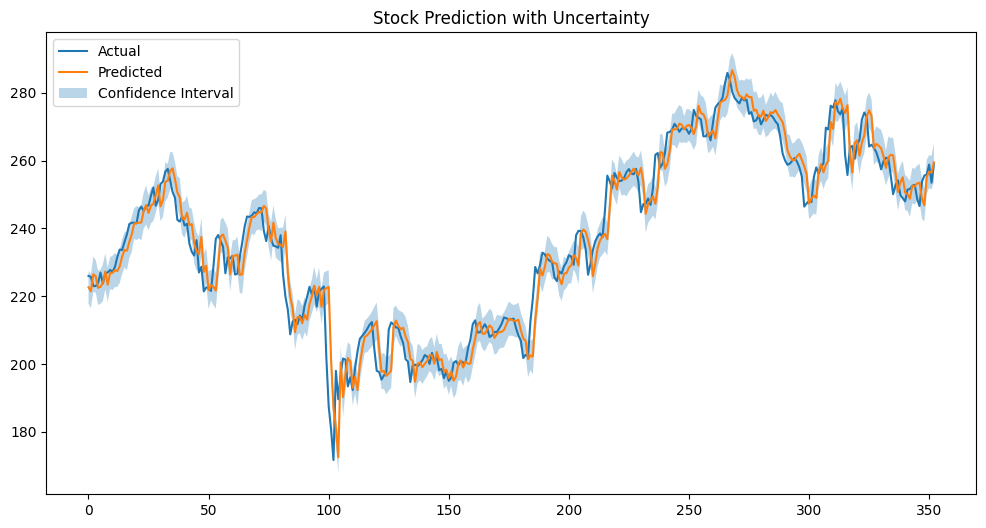

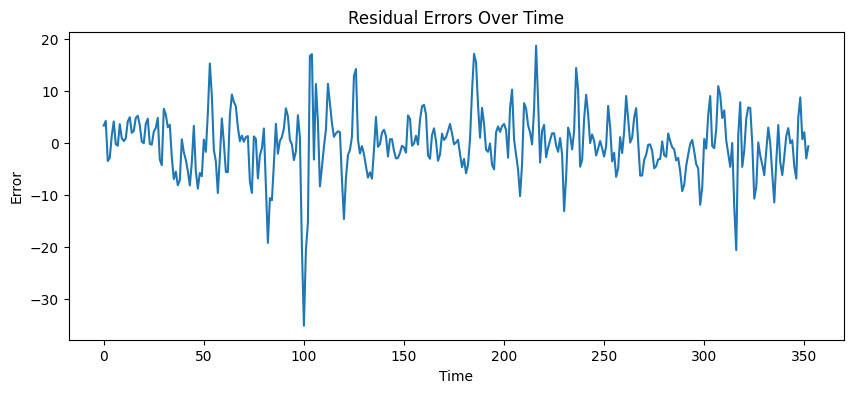

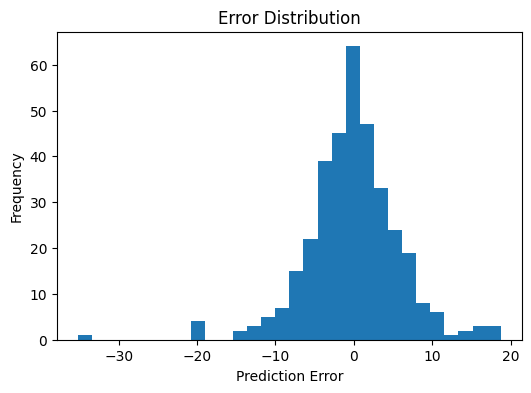


📊 Confidence Interval Coverage: 69.41%


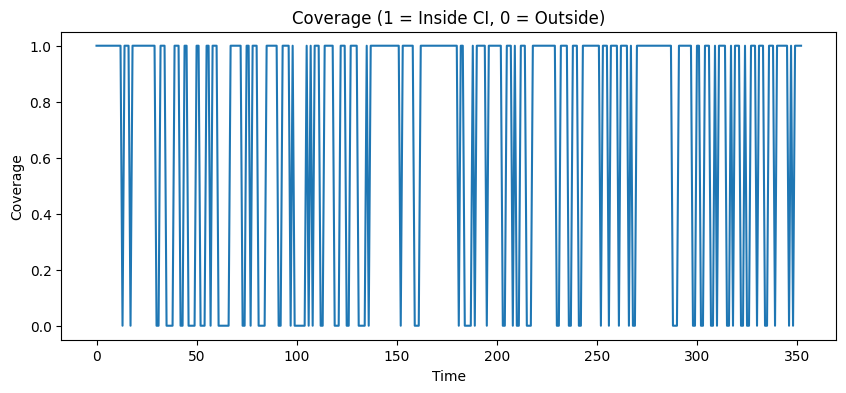

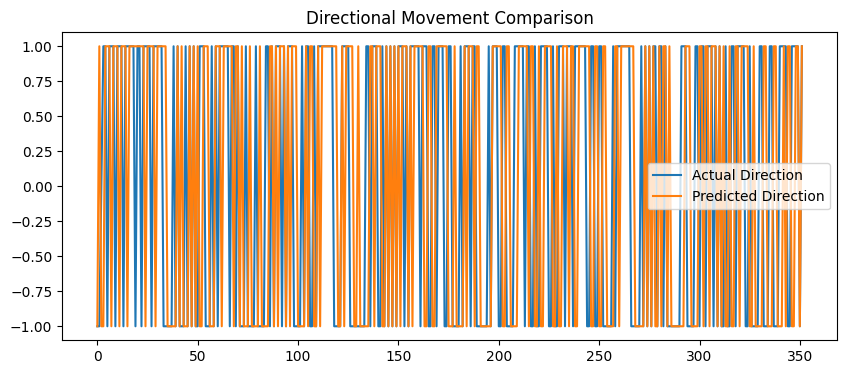

In [ ]:
# ===========================
# INSTALL (run once)
# ===========================
# !pip install yfinance pandas numpy matplotlib scikit-learn statsmodels torch

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# ===========================
# 1. LOAD DATA
# ===========================
def load_data(ticker="AAPL"):
    df = yf.download(ticker, period="5y", auto_adjust=True)

    df = df[['Open','High','Low','Close','Volume']]

    # flatten columns
    df.columns = ['Open','High','Low','Close','Volume']
    for col in df.columns:
        df[col] = df[col].values.flatten()

    df.index = pd.to_datetime(df.index)
    df = df.asfreq('B')

    df.dropna(inplace=True)
    return df

# ===========================
# 2. FEATURES
# ===========================
def add_features(df):
    df['SMA7'] = df['Close'].rolling(7).mean()
    df['SMA21'] = df['Close'].rolling(21).mean()

    df['EMA12'] = df['Close'].ewm(span=12).mean()
    df['EMA26'] = df['Close'].ewm(span=26).mean()

    delta = df['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    high_low = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift()).abs()
    low_close = (df['Low'] - df['Close'].shift()).abs()

    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    df['ATR'] = ranges.max(axis=1).rolling(14).mean()

    df['Returns'] = df['Close'].pct_change()
    df['Volatility'] = df['Returns'].rolling(10).std()

    df.dropna(inplace=True)
    return df

# ===========================
# 3. ARIMA
# ===========================
def fit_arima(series):
    return ARIMA(series, order=(5,1,0)).fit()

def get_residuals(model, series):
    preds = model.predict(start=1, end=len(series)-1)
    preds = np.array(preds).reshape(-1)
    actual = np.array(series)[1:].reshape(-1)
    return actual - preds

# ===========================
# 4. SEQUENCES
# ===========================
def create_sequences(data, target, seq_len=60):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

# ===========================
# 5. MODEL
# ===========================
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, 128, batch_first=True)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.attn = Attention(64)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x,_ = self.lstm1(x)
        x,_ = self.lstm2(x)
        x = self.attn(x)
        x = self.dropout(x)
        return self.fc(x)

# ===========================
# 6. TRAIN
# ===========================
def train_model(model, X, y):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).squeeze()

    for epoch in range(25):
        model.train()
        optimizer.zero_grad()
        output = model(X_t).squeeze()
        loss = loss_fn(output, y_t)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

# ===========================
# 7. MC DROPOUT
# ===========================
def mc_predict(model, X, n_samples=100):
    model.train()
    preds = []
    X_t = torch.tensor(X, dtype=torch.float32)

    for _ in range(n_samples):
        preds.append(model(X_t).detach().numpy())

    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

# ===========================
# MAIN PIPELINE
# ===========================
df = load_data()
df = add_features(df)

# ARIMA
arima_model = fit_arima(df['Close'])
residuals = get_residuals(arima_model, df['Close'])

df = df.iloc[1:].copy()
df['Residual'] = residuals

# SCALE
feature_scaler = MinMaxScaler()
features_scaled = feature_scaler.fit_transform(df.drop(columns=['Residual']))

res_scaler = MinMaxScaler()
residuals_scaled = res_scaler.fit_transform(df[['Residual']])

# SEQUENCES
X, y = create_sequences(features_scaled, residuals_scaled)

# SPLIT
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# MODEL
model = LSTMModel(input_dim=X.shape[2])
model = train_model(model, X_train, y_train)

# PREDICT
mean, std = mc_predict(model, X_test)

mean = res_scaler.inverse_transform(mean)
std = std * res_scaler.data_range_

# ARIMA predictions
arima_preds = arima_model.predict(start=split+60, end=len(df)-1)

# FINAL
final_pred = arima_preds.values.reshape(-1,1) + mean

# ALIGN LENGTHS
actual = df['Close'].values[-len(final_pred):]

# ===========================
# METRICS (FIXED)
# ===========================
rmse = np.sqrt(mean_squared_error(actual, final_pred))
mae = mean_absolute_error(actual, final_pred)
mape = np.mean(np.abs((actual - final_pred.flatten()) / actual)) * 100

# FIXED directional accuracy
min_len = min(len(actual), len(final_pred))

direction_pred = np.sign(np.diff(final_pred.flatten()[:min_len]))
direction_actual = np.sign(np.diff(actual[:min_len]))

direction_acc = np.mean(direction_pred == direction_actual) * 100

print("\n📊 METRICS:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"Directional Accuracy: {direction_acc:.2f}%")

# ===========================
# GRAPH
# ===========================
lower = final_pred - 1.96 * std
upper = final_pred + 1.96 * std

plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual')
plt.plot(final_pred, label='Predicted')

plt.fill_between(range(len(final_pred)),
                 lower.flatten(),
                 upper.flatten(),
                 alpha=0.3,
                 label='Confidence Interval')

plt.legend()
plt.title("Stock Prediction with Uncertainty")
plt.show()

# ===========================
# EXTRA ANALYSIS + GRAPHS
# ===========================

# Ensure alignment
actual = actual.flatten()
pred = final_pred.flatten()
lower = lower.flatten()
upper = upper.flatten()

min_len = min(len(actual), len(pred))
actual = actual[:min_len]
pred = pred[:min_len]
lower = lower[:min_len]
upper = upper[:min_len]

# ===========================
# 1. RESIDUAL PLOT
# ===========================
residuals_plot = actual - pred

plt.figure(figsize=(10,4))
plt.plot(residuals_plot)
plt.title("Residual Errors Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

# ===========================
# 2. ERROR DISTRIBUTION
# ===========================
plt.figure(figsize=(6,4))
plt.hist(residuals_plot, bins=30)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

# ===========================
# 3. COVERAGE (KEY FOR PAPER)
# ===========================
within_interval = np.logical_and(actual >= lower, actual <= upper)
coverage = np.mean(within_interval) * 100

print(f"\n📊 Confidence Interval Coverage: {coverage:.2f}%")

# ===========================
# 4. COVERAGE VISUAL
# ===========================
plt.figure(figsize=(10,4))
plt.plot(within_interval.astype(int))
plt.title("Coverage (1 = Inside CI, 0 = Outside)")
plt.xlabel("Time")
plt.ylabel("Coverage")
plt.show()

# ===========================
# 5. DIRECTION VISUAL
# ===========================
direction_pred = np.sign(np.diff(pred))
direction_actual = np.sign(np.diff(actual))

plt.figure(figsize=(10,4))
plt.plot(direction_actual, label="Actual Direction")
plt.plot(direction_pred, label="Predicted Direction")
plt.legend()
plt.title("Directional Movement Comparison")
plt.show()

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Epoch 0, Loss: 0.3584
Epoch 1, Loss: 0.3125
Epoch 2, Loss: 0.2661
Epoch 3, Loss: 0.2195
Epoch 4, Loss: 0.1779
Epoch 5, Loss: 0.1371
Epoch 6, Loss: 0.0944
Epoch 7, Loss: 0.0519
Epoch 8, Loss: 0.0230
Epoch 9, Loss: 0.0217
Epoch 10, Loss: 0.0507
Epoch 11, Loss: 0.0557
Epoch 12, Loss: 0.0395
Epoch 13, Loss: 0.0242
Epoch 14, Loss: 0.0154
Epoch 15, Loss: 0.0142
Epoch 16, Loss: 0.0162
Epoch 17, Loss: 0.0190
Epoch 18, Loss: 0.0205
Epoch 19, Loss: 0.0227
Epoch 20, Loss: 0.0222
Epoch 21, Loss: 0.0223
Epoch 22, Loss: 0.0208
Epoch 23, Loss: 0.0186
Epoch 24, Loss: 0.0151

📊 FINAL MODEL
RMSE: 6.36
MAE: 4.61
MAPE: 1.98%

📊 CONFIDENCE INTERVAL METRICS
Average Interval Width: 12.05
Interval Score: 51.83
Coverage: 90.37%


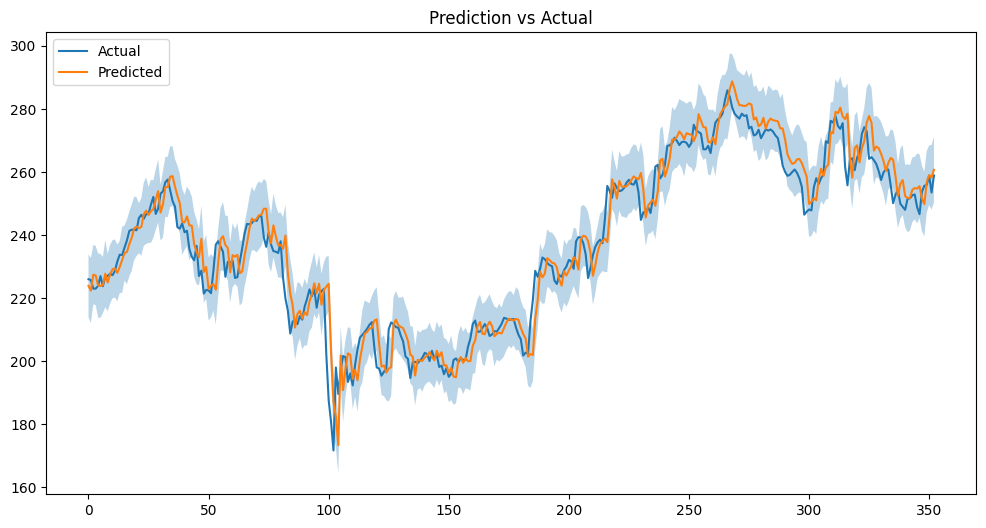

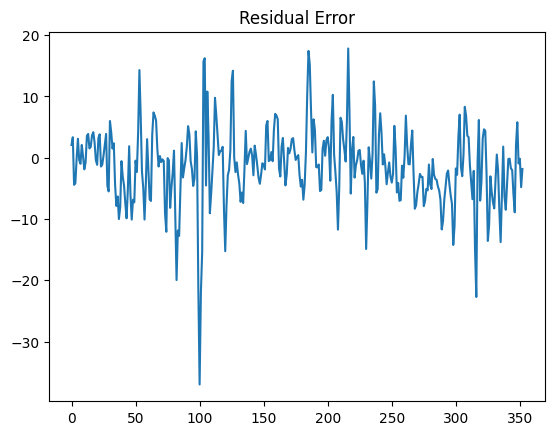

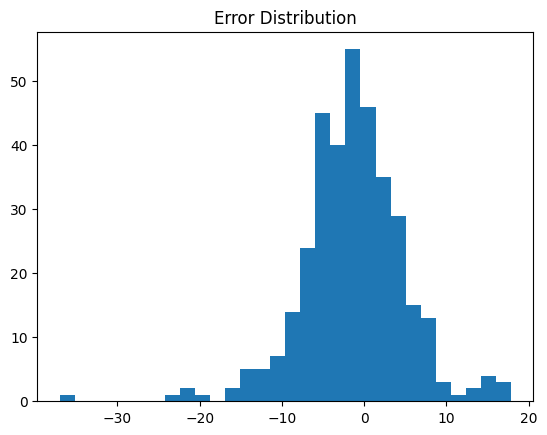

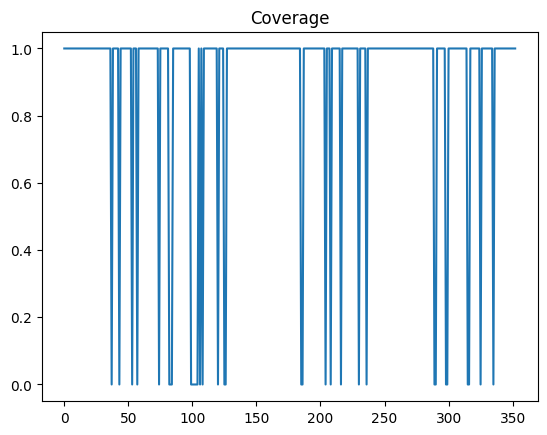

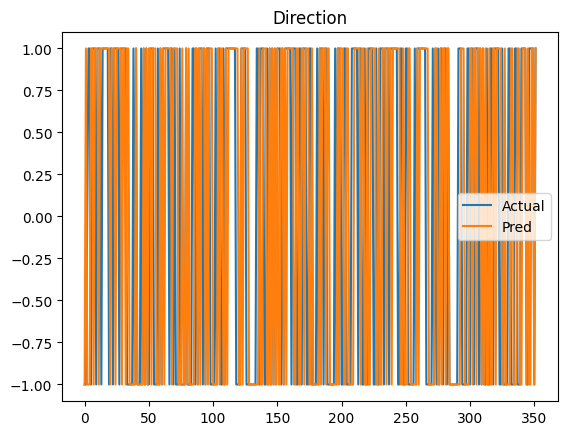

In [ ]:
# ===========================
# INSTALL (run once)
# ===========================
# !pip install yfinance pandas numpy matplotlib scikit-learn statsmodels torch

import numpy as np
import pandas as pd
import yfinance as yf
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# ===========================
# LOAD DATA (FIXED)
# ===========================
def load_data(ticker="AAPL"):
    df = yf.download(ticker, period="5y", auto_adjust=True)

    df = df[['Open','High','Low','Close','Volume']].copy()
    df.columns = ['Open','High','Low','Close','Volume']

    df.reset_index(drop=True, inplace=True)
    df.dropna(inplace=True)
    return df

# ===========================
# FEATURES
# ===========================
def add_features(df):
    df['SMA7'] = df['Close'].rolling(7).mean()
    df['SMA21'] = df['Close'].rolling(21).mean()
    df['EMA12'] = df['Close'].ewm(span=12).mean()
    df['EMA26'] = df['Close'].ewm(span=26).mean()

    delta = df['Close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['Returns'] = df['Close'].pct_change()
    df['Volatility'] = df['Returns'].rolling(10).std()

    df.dropna(inplace=True)
    return df

# ===========================
# ARIMA
# ===========================
def fit_arima(series):
    return ARIMA(series, order=(5,1,0)).fit()

def get_residuals(model, series):
    preds = model.predict(start=1, end=len(series)-1)

    preds = np.asarray(preds).reshape(-1)
    actual = np.asarray(series).reshape(-1)[1:]

    min_len = min(len(preds), len(actual))
    preds = preds[:min_len]
    actual = actual[:min_len]

    return actual - preds

# ===========================
# SEQUENCES
# ===========================
def create_sequences(data, target, seq_len=60):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

# ===========================
# MODEL (ATTENTION LSTM)
# ===========================
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return torch.sum(weights * x, dim=1)

class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, 128, batch_first=True)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.attn = Attention(64)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x,_ = self.lstm1(x)
        x,_ = self.lstm2(x)
        x = self.attn(x)
        x = self.dropout(x)
        return self.fc(x)

# ===========================
# TRAIN
# ===========================
def train_model(model, X, y):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).squeeze()

    for epoch in range(25):
        model.train()
        optimizer.zero_grad()
        output = model(X_t).squeeze()
        loss = loss_fn(output, y_t)
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

# ===========================
# MC DROPOUT
# ===========================
def mc_predict(model, X, n=100):
    model.train()
    preds = []
    X_t = torch.tensor(X, dtype=torch.float32)

    for _ in range(n):
        preds.append(model(X_t).detach().numpy())

    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

# ===========================
# PIPELINE
# ===========================
df = load_data()
df = add_features(df)

# ARIMA
arima_model = fit_arima(df['Close'])
residuals = get_residuals(arima_model, df['Close'])

df = df.iloc[1:].copy()
residuals = residuals[:len(df)]
df.loc[:, 'Residual'] = residuals

# SCALE
features = df.drop(columns=['Residual']).values
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(features)

res_scaler = MinMaxScaler()
y_scaled = res_scaler.fit_transform(df[['Residual']])

# SEQUENCES
X, y = create_sequences(X_scaled, y_scaled)

split = int(0.7*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# MODEL
model = LSTMModel(X.shape[2])
model = train_model(model, X_train, y_train)

# PREDICT
mean, std = mc_predict(model, X_test)

mean = res_scaler.inverse_transform(mean)
std = std * res_scaler.data_range_

# ALIGNMENT
arima_future = arima_model.predict(start=len(df)-len(mean), end=len(df)-1)

final_pred = arima_future.values.reshape(-1,1) + mean
actual = df['Close'].values[-len(final_pred):]

# ===========================
# METRICS (FIXED)
# ===========================
pred = final_pred.flatten()

rmse = np.sqrt(mean_squared_error(actual, pred))
mae = mean_absolute_error(actual, pred)
mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100

print("\n📊 FINAL MODEL")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

# ===========================
# CONFIDENCE INTERVAL METRICS
# ===========================

# Flatten everything
actual = actual.flatten()
lower = lower.flatten()
upper = upper.flatten()

# 1. Average Interval Width
interval_width = np.mean(upper - lower)

# 2. Interval Score (proper scoring rule)
# alpha = 0.05 for 95% interval
alpha = 0.05

penalty_lower = (2/alpha) * (lower - actual) * (actual < lower)
penalty_upper = (2/alpha) * (actual - upper) * (actual > upper)

interval_score = np.mean((upper - lower) + penalty_lower + penalty_upper)

print("\n📊 CONFIDENCE INTERVAL METRICS")
print(f"Average Interval Width: {interval_width:.2f}")
print(f"Interval Score: {interval_score:.2f}")

# ===========================
# UNCERTAINTY (FIXED)
# ===========================
lower = final_pred - 2.5*std
upper = final_pred + 2.5*std

coverage = np.mean((actual>=lower.flatten())&(actual<=upper.flatten()))*100
print(f"Coverage: {coverage:.2f}%")

# ===========================
# 5 GRAPHS
# ===========================
actual = actual.flatten()
pred = pred
lower = lower.flatten()
upper = upper.flatten()

# 1 Prediction
plt.figure(figsize=(12,6))
plt.plot(actual,label="Actual")
plt.plot(pred,label="Predicted")
plt.fill_between(range(len(pred)),lower,upper,alpha=0.3)
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

# 2 Residual
res = actual - pred
plt.figure()
plt.plot(res)
plt.title("Residual Error")
plt.show()

# 3 Histogram
plt.figure()
plt.hist(res,bins=30)
plt.title("Error Distribution")
plt.show()

# 4 Coverage
inside = (actual>=lower)&(actual<=upper)
plt.figure()
plt.plot(inside.astype(int))
plt.title("Coverage")
plt.show()

# 5 Direction
plt.figure()
plt.plot(np.sign(np.diff(actual)),label="Actual")
plt.plot(np.sign(np.diff(pred)),label="Pred")
plt.legend()
plt.title("Direction")
plt.show()